In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision.transforms as transforms
import os
import numpy as np

sns.set_theme(style="whitegrid")

C:\Users\nicol\AppData\Local\Temp\ipykernel_3132\3431266293.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(statistici_clase.values()), y=list(statistici_clase.keys()), palette='magma')


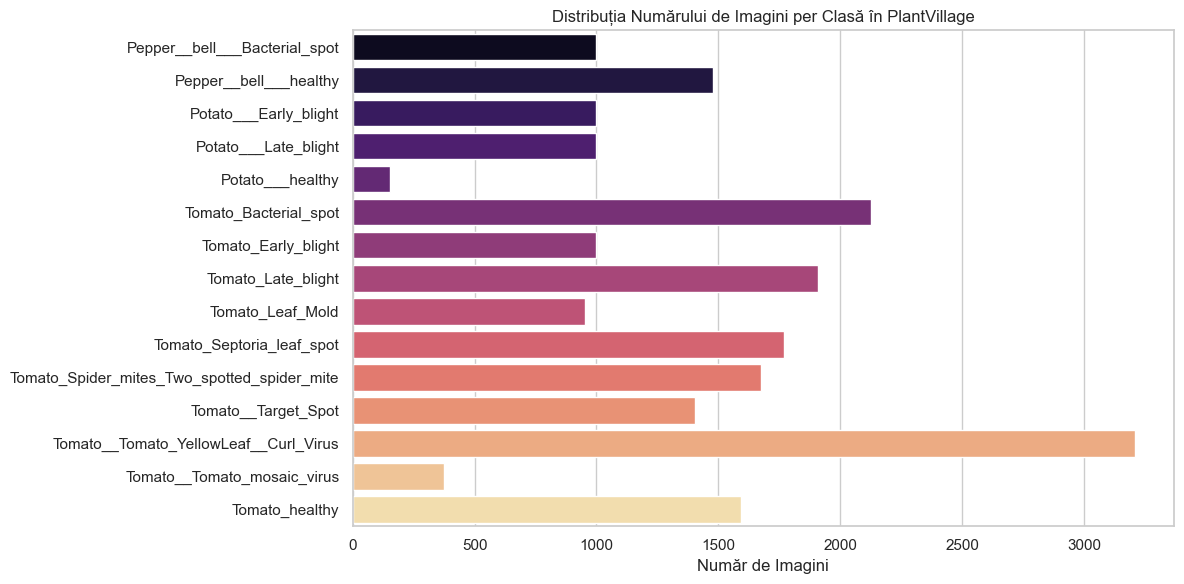

In [2]:
cale_foldere = "../data/raw/plantvillage/"
clase = sorted(os.listdir(cale_foldere))

statistici_clase = {}
for c in clase:
    cale_clasa = os.path.join(cale_foldere, c)
    if os.path.isdir(cale_clasa):
        statistici_clase[c] = len(os.listdir(cale_clasa))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(statistici_clase.values()), y=list(statistici_clase.keys()), palette='magma')
plt.title('Distribuția Numărului de Imagini per Clasă în PlantVillage')
plt.xlabel('Număr de Imagini')
plt.tight_layout()
plt.show()

In [3]:
dimensiuni = []
intensitati_medii = []

for c in clase[:3]:
    cale_clasa = os.path.join(cale_foldere, c)
    if os.path.isdir(cale_clasa):
        for img_name in os.listdir(cale_clasa)[:10]:
            img_path = os.path.join(cale_clasa, img_name)
            with Image.open(img_path) as img:
                dimensiuni.append(img.size)
                intensitati_medii.append(np.mean(np.array(img)))

print(set(dimensiuni))
print(np.mean(intensitati_medii))

{(256, 256)}
120.77457478841147


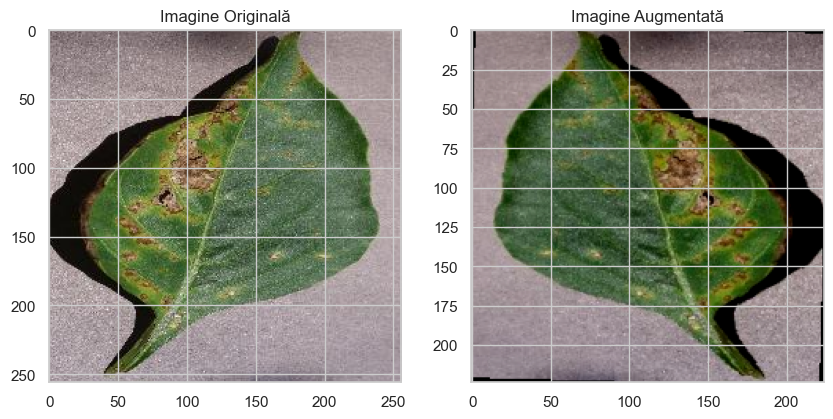

In [4]:
transform_vizualizare = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4)
])

prima_clasa = os.path.join(cale_foldere, clase[0])
img_test_path = os.path.join(prima_clasa, os.listdir(prima_clasa)[0])
img_originala = Image.open(img_test_path)
img_augmentata = transform_vizualizare(img_originala)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_originala)
ax[0].set_title("Imagine Originală")
ax[1].imshow(img_augmentata)
ax[1].set_title("Imagine Augmentată")
plt.show()